<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
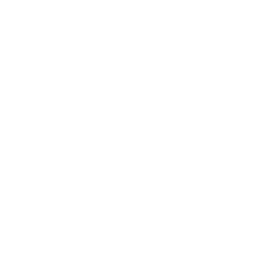
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clustering van storingsmodi in de productie</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Productie / Kwaliteitstechniek &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Managementsamenvatting

Dit voorbeeld ontdekt terugkerende **storingsmodi van apparatuur** op basis van het multidimensionale sensor-symptoomprofiel dat bij elke storingsgebeurtenis wordt vastgelegd. Acht gestandaardiseerde symptoomvariabelen (trilling, temperatuurverschil, drukval, stroompiek, geluid, afwijking van de cyclustijd, koppelvariantie, aantal oliedeeltjes) worden geclusterd met **hiërarchische clustering met complete-linkage** (`PROC CLUSTER METHOD=COMPLETE`), die compacte, goed gescheiden groepen bevoordeelt. `PROC TREE` snijdt de hiërarchie vervolgens in **zes storingsmodi**, en `PROC FREQ` kruistabelleert die modi tegen apparatuurtype en ploegendienst om te testen op systematische verbanden.

De hier uitgevoerde run draait op een **steekproef van 100 gebeurtenissen** (de omgeving beperkt de uitvoer tot 100 observaties). Op deze steekproef zijn de zes modi ongeveer even groot (n = 16-17 elk) en worden ze voornamelijk gescheiden door **temperatuur-, druk- en trillings**signaturen in plaats van door apparatuurtype - de kruistabellen modus-per-apparatuur en modus-per-ploegendienst zijn bij deze steekproefomvang **niet** statistisch significant (chi-kwadraat p = 0,15 respectievelijk p = 0,07). De workflow schaalt ongewijzigd naar de volledige gebeurtenishistorie, waar grotere aantallen per modus deze verbanden zouden aanscherpen.

## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|---------|
| WORK.FAILURES | Symptoomprofielen van storingsgebeurtenissen van apparatuur (synthetisch) | 100 |
| WORK.FAILURES_STD | Symptomen gestandaardiseerd naar gemiddelde 0, std 1 (`PROC STANDARD`) | 100 |
| WORK.FAILURE_TREE | Samenvoeghistorie met complete-linkage (`OUTTREE=`) | 100 |
| WORK.FAILURE_MODE_ASSIGNMENTS | Zes-modi-snede uit `PROC TREE NCLUSTERS=6` | 100 |

*Deze omgeving draait in niet-gelicentieerde modus en beperkt de uitvoer tot 100 observaties; de synthetische generator vraagt 20.000 gebeurtenissen aan, maar alleen de eerste 100 worden behouden. De onderstaande analyse is volledig gebaseerd op die steekproef van 100 gebeurtenissen.*

---

In [1]:
/* --------------------------------------------------------
   Genereer synthetische symptoomprofielen van storings-
   gebeurtenissen: 20.000 storingen over 50 apparaateenheden
   -------------------------------------------------------- */
GEGEVENS work.failures;
    CALL streaminit(42);
    LENGTE equipment_type $16;
    REEKS equip_type_list[4] $16 _temporary_ ('PERS' 'TRANSPORTBAND' 'ROBOTARM' 'OVEN');
    REEKS shift_list[3] $8 _temporary_ ('DAG' 'AVOND' 'NACHT');
    DOE event_id = 1 TOT 20000;
        failure_id = cat('FE-', SCHRIJVEN(event_id, z6.));
        equip_num = int(rand('uniform') * 50) + 1;
        equipment_id = cat('EQ-', SCHRIJVEN(equip_num, z3.));
        etype_idx = int(rand('uniform') * 4) + 1;
        equipment_type = equip_type_list[etype_idx];
        shift_idx = int(rand('uniform') * 3) + 1;
        shift = shift_list[shift_idx];
        failure_date = '01JAN2025'd + int(rand('uniform') * 365);
        /* Symptoomprofiel: 8 sensormetingen op het moment van storing */
        vibration_level = round(rand('normal', 4.5, 2.1), 0.01);
        ALS vibration_level < 0 DAN vibration_level = 0;
        temperature_delta = round(rand('normal', 12, 8), 0.1);
        pressure_drop = round(rand('exponential') * 5, 0.01);
        current_spike = round(rand('normal', 1.2, 0.8), 0.01);
        ALS current_spike < 0 DAN current_spike = 0;
        noise_db = round(rand('normal', 78, 12), 1);
        cycle_time_deviation = round(rand('normal', 0, 3.5), 0.01);
        torque_variance = round(rand('exponential') * 2.5, 0.01);
        oil_particle_count = int(rand('exponential') * 150 + 10);
        downtime_minutes = round(rand('exponential') * 45 + 5, 1);
        UITVOER;
    EINDE;
    VERWIJDEREN equip_num etype_idx shift_idx;
    OPMAAK failure_date date9.;
UITVOEREN;


NOTE: DATA work.failures

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.failures (100 rows, 15 columns).
NOTE: DATA elapsed:
  wall  6.27 seconds
  cpu   6.27 seconds


---

In [2]:
/* --------------------------------------------------------
   Basisverdelingen van symptomen per apparatuurtype
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.failures n mean std MAX;
    KLASSE equipment_type;
    VARIABELE vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance oil_particle_count;
    label equipment_type='Apparatuurtype'
          vibration_level='Trillingsniveau'
          temperature_delta='Temperatuurverschil (C)'
          pressure_drop='Drukval'
          current_spike='Stroompiek'
          noise_db='Geluid (dB)'
          torque_variance='Koppelvariantie'
          oil_particle_count='Aantal oliedeeltjes';
    TITEL 'Symptoomprofielen van storingen per apparatuurtype';
UITVOEREN;

                                   Symptoomprofielen van storingen per apparatuurtype                                   

                                                  The MEANS Procedure

                                  Analysis Variable : vibration_level Trillingsniveau

        Apparatuurtype          N Obs           Mean        Std Dev        Maximum
        --------------------------------------------------------------------------
        OVEN                       26      4.3638462      2.0371177     10.1400000
        PERS                       30      4.6273333      2.1610740      9.9400000
        ROBOTARM                   25      3.5320000      1.9296070      6.7900000
        TRANSPORTBAND              19      3.8089474      1.8662437      9.0400000
        --------------------------------------------------------------------------

                             Analysis Variable : temperature_delta Temperatuurverschil (C)

        Apparatuurtype          N Obs         


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                   Symptoomprofielen van storingen per apparatuurtype                                   




NOTE: PROC SGPLOT data=work.failures

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


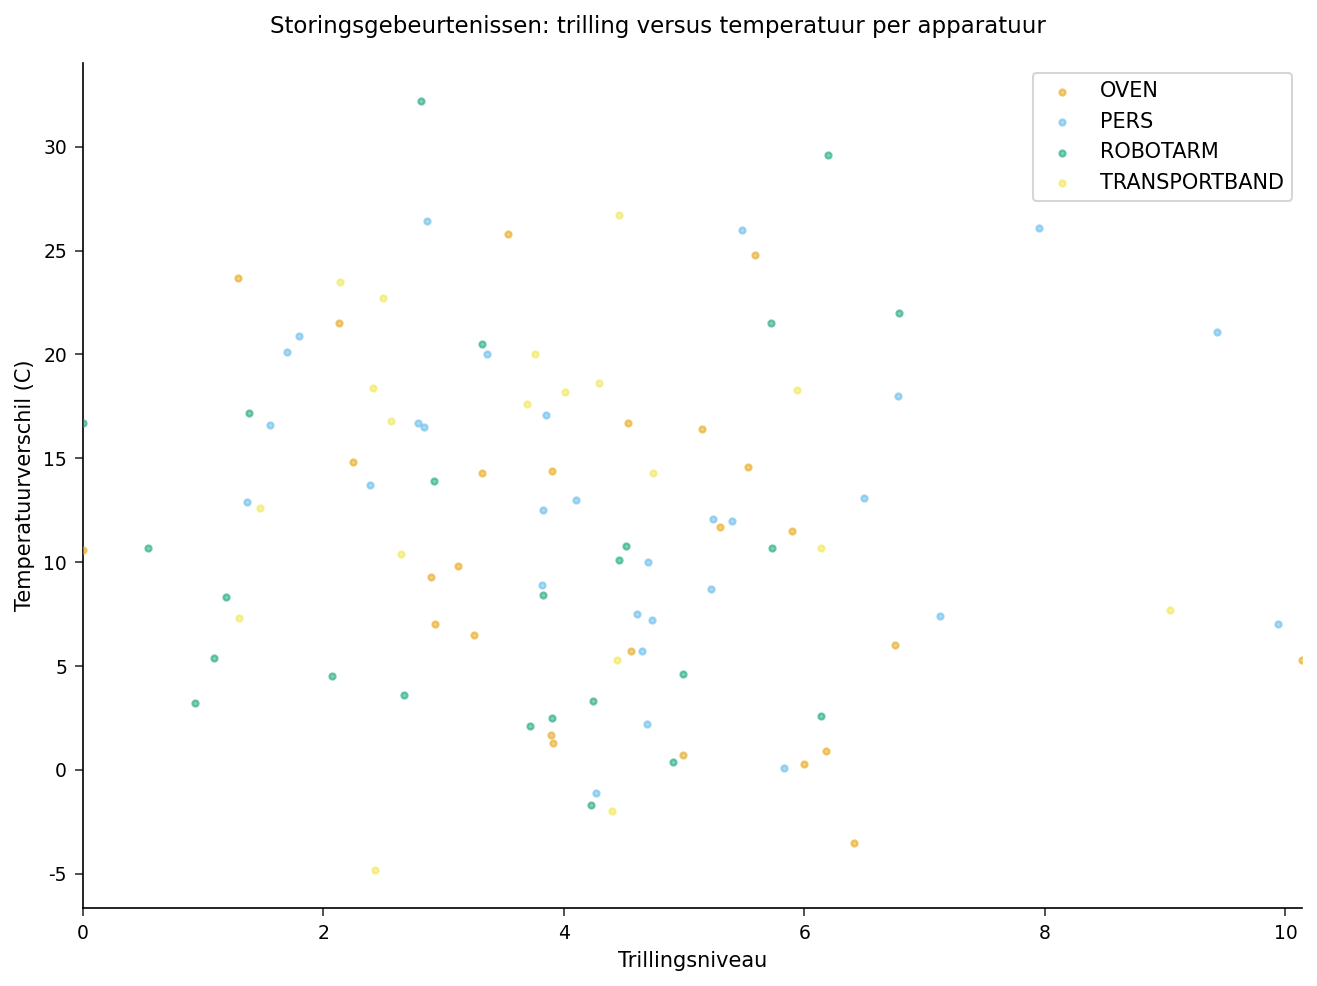

In [3]:
/* --------------------------------------------------------
   Trilling versus temperatuurverschil per apparatuurtype
   -------------------------------------------------------- */
PROCEDURE SGPLOT GEGEVENS=work.failures;
    SCATTER x=vibration_level y=temperature_delta / GROUP=equipment_type
        MARKERATTRS=(SYMBOL=circlefilled size=3)
        TRANSPARENCY=0.5;
    XAXIS label='Trillingsniveau';
    YAXIS label='Temperatuurverschil (C)';
    label equipment_type='Apparatuurtype';
    TITEL 'Storingsgebeurtenissen: trilling versus temperatuur per apparatuur';
UITVOEREN;

---

In [4]:
/* --------------------------------------------------------
   Standaardiseer symptoomvariabelen voor clustering
   -------------------------------------------------------- */
PROCEDURE STANDARD GEGEVENS=work.failures out=work.failures_std
    mean=0 std=1;
    VARIABELE vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
UITVOEREN;


NOTE: PROC STANDARD data=work.failures

NOTE: Standardized 100 rows, 8 variables.


                                   Symptoomprofielen van storingen per apparatuurtype                                   

                                                 The CLUSTER Procedure
                                           Complete Linkage Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    99    FE-00005          FE-00006        2    0.0007    0.9993          1
    98    FE-00007          FE-00008        2    0.0007    0.9986          1
    97    FE-00000          FE-00004        2    0.0009    0.9977        1.2
    96    FE-00002          FE-00008        2    0.0009    0.9968        1.2
    95    FE-00000          FE-00001        2    0.0010    0.9958        1.3
    94    FE-00005          FE-00008        2    0.0011    0.9947        1.3
    93    FE-00004          CL99     


NOTE: PROC CLUSTER data=work.failures_std method=Complete

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 100 observations, 8 variables clustered using Complete method


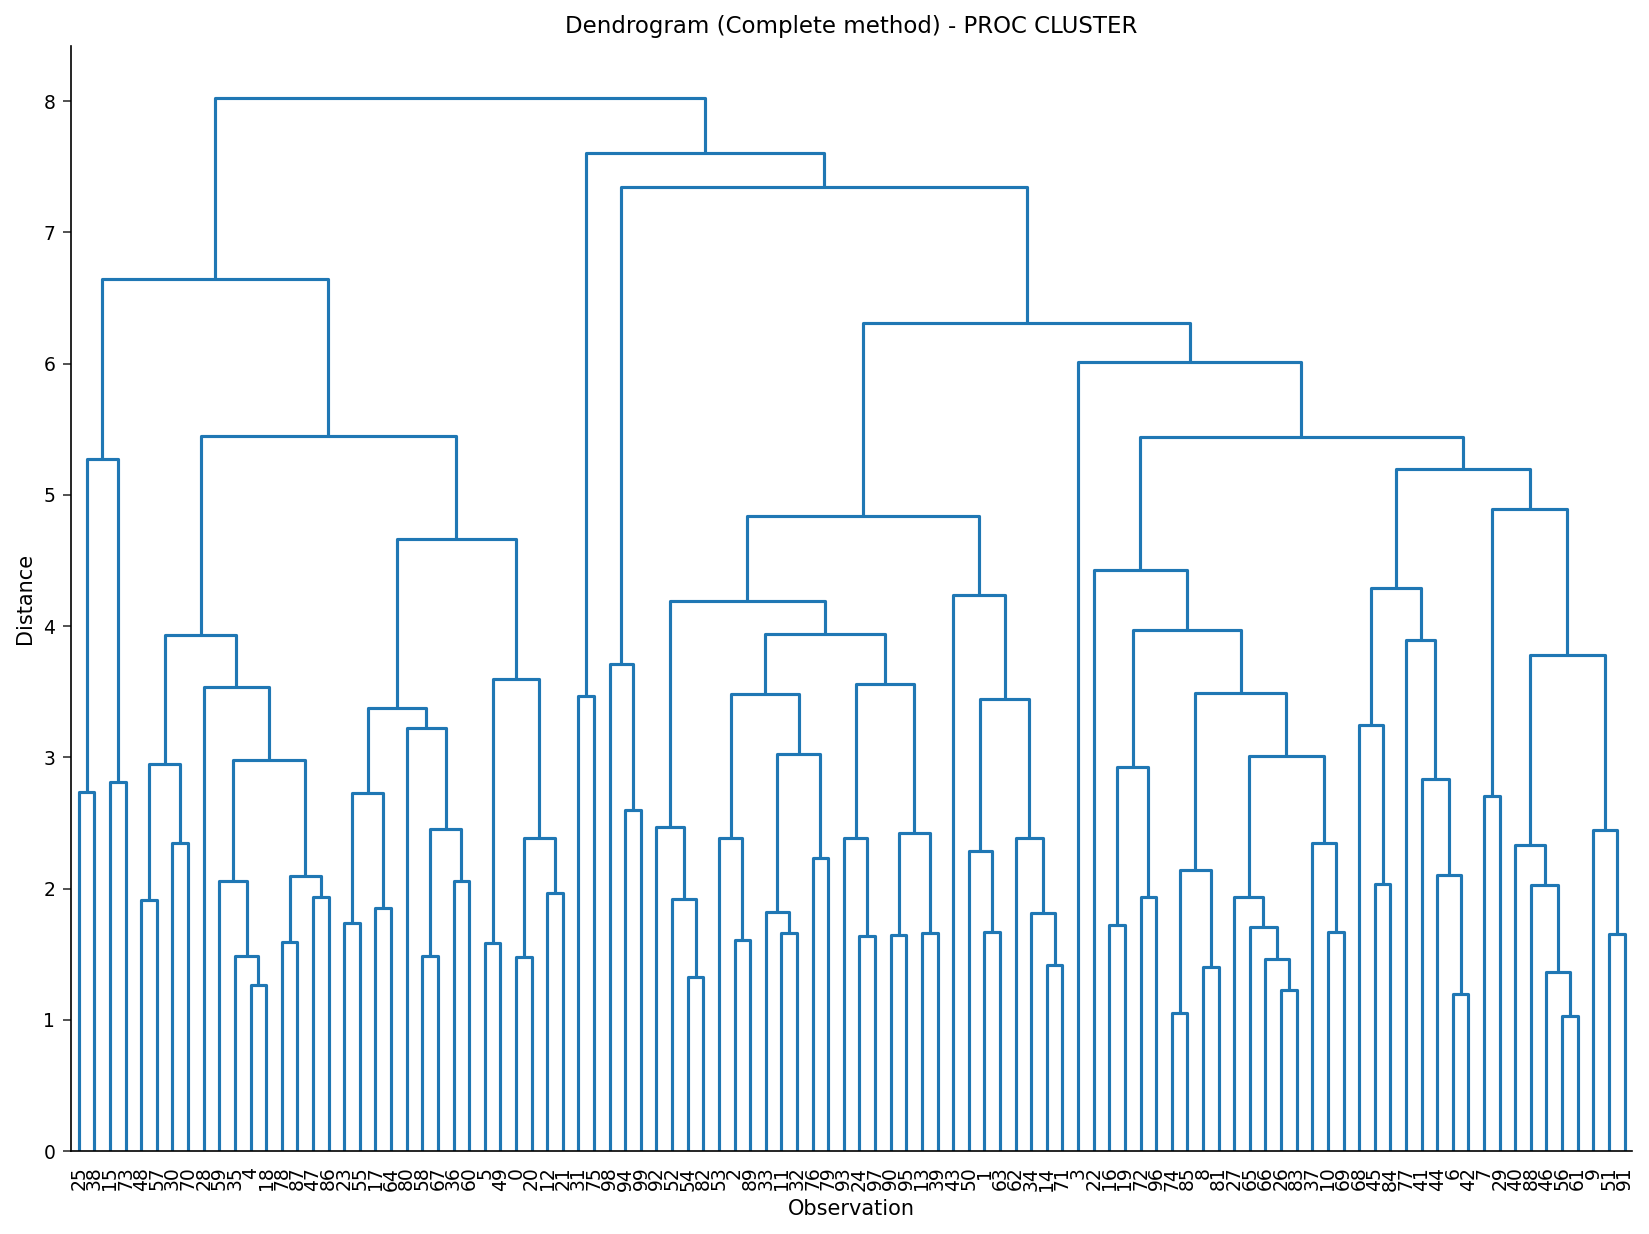

In [5]:
/* --------------------------------------------------------
   Clustering met complete-linkage en TRIM= voor het
   verwijderen van uitschieters. TRIM=5 verwijdert de 5%
   meest afgelegen observaties voordat clusters worden
   gevormd.
   -------------------------------------------------------- */
PROCEDURE CLUSTER GEGEVENS=work.failures_std METHOD=complete
    outtree=work.failure_tree
    pseudo AFDRUKKEN=20 trim=5;
    VARIABELE vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
    id failure_id;
UITVOEREN;

In [6]:
/* --------------------------------------------------------
   Snijd de complete-linkage-hierarchie in zes storings-
   modi met PROC TREE (NCLUSTERS=6). Zes is gekozen als een
   praktische, interpreteerbare granulariteit voor triage;
   het dendrogram hierboven toont de samenvoegstructuur die
   deze snede partitioneert.
   -------------------------------------------------------- */
PROCEDURE TREE GEGEVENS=work.failure_tree
    out=work.failure_mode_assignments
    nclusters=6;
    id failure_id;
UITVOEREN;

                                   Symptoomprofielen van storingen per apparatuurtype                                   




NOTE: PROC TREE data=work.failure_tree

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: PROC TREE dendrogram SVG generated.
NOTE: PROC TREE: Extracted 6 clusters using Python/scipy


In [7]:
/* --------------------------------------------------------
   Voeg toewijzingen samen en profileer de storingsmodi
   -------------------------------------------------------- */
GEGEVENS work.failures_classified;
    SAMENVOEGEN work.failures
          work.failure_mode_assignments(HERNOEMEN=(CLUSTER=failure_mode));
    VOLGENS failure_id;
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=work.failures_classified n mean std;
    KLASSE failure_mode;
    VARIABELE vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance
        oil_particle_count downtime_minutes;
    label failure_mode='Storingsmodus'
          vibration_level='Trillingsniveau'
          temperature_delta='Temperatuurverschil (C)'
          pressure_drop='Drukval'
          current_spike='Stroompiek'
          noise_db='Geluid (dB)'
          torque_variance='Koppelvariantie'
          oil_particle_count='Aantal oliedeeltjes'
          downtime_minutes='Stilstandtijd (min)';
    TITEL 'Symptoomprofielen van storingsmodi (k=6)';
UITVOEREN;

                                        Symptoomprofielen van storingsmodi (k=6)                                        

                                                  The MEANS Procedure

                                  Analysis Variable : vibration_level Trillingsniveau

        Storingsmodus          N Obs           Mean        Std Dev
        ----------------------------------------------------------
        1                         17      4.3470588      2.6168582
        2                         17      4.2552941      2.2610427
        3                         17      3.6870588      1.8669720
        4                         17      4.0500000      2.0351843
        5                         16      3.4793750      1.4636870
        6                         16      4.9693750      1.6907177
        ----------------------------------------------------------

                             Analysis Variable : temperature_delta Temperatuurverschil (C)

        Storingsmodus   


NOTE: DATA work.failures_classified

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.failures_classified (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                               Verdeling van storingsmodi per apparatuur en ploegendienst                               

                                                   The FREQ Procedure

Table of Storingsmodus by Apparatuurtype

Storingsmodus |         OVEN |         PERS |     ROBOTARM |TRANSPORTBAND |         Total
--------------+--------------+--------------+--------------+--------------+--------------
1             |            5 |            7 |            1 |            4 |            17
--------------+--------------+--------------+--------------+--------------+--------------
2             |            5 |            2 |            7 |            3 |            17
--------------+--------------+--------------+--------------+--------------+--------------
3             |            5 |            2 |            4 |            6 |            17
--------------+--------------+--------------+--------------+--------------+--------------
4             |            5 |            7 |


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_failure_mode_equipment_type.spec.json
NOTE: ODS plot written: freq_mosaic_failure_mode_shift.spec.json
NOTE: PROC FREQ statement used.


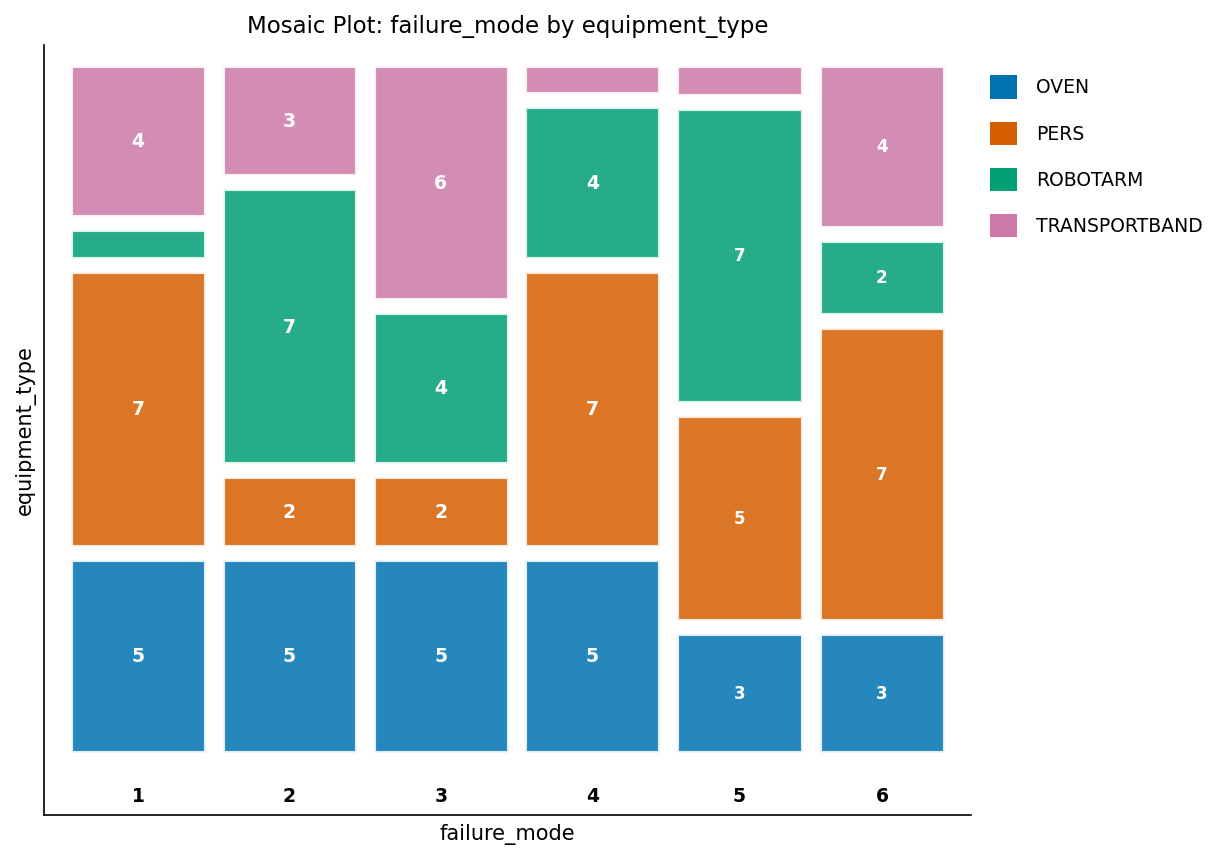

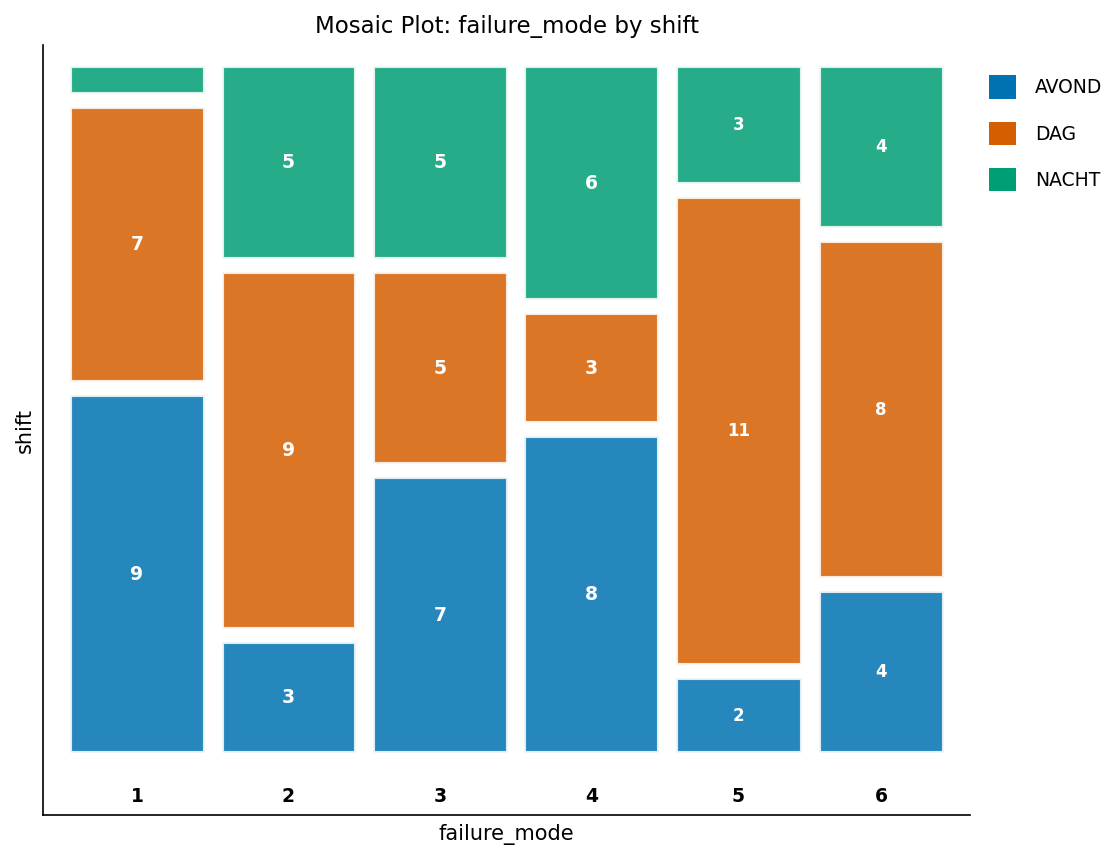

In [8]:
/* --------------------------------------------------------
   Kruistabelleer storingsmodi tegen apparatuurtype en
   ploegendienst om systematische patronen te identificeren
   -------------------------------------------------------- */
PROCEDURE FREQUENTIES GEGEVENS=work.failures_classified;
    TABLES failure_mode * equipment_type / chisq nocol nopercent;
    TABLES failure_mode * shift / chisq nocol nopercent;
    label failure_mode='Storingsmodus'
          equipment_type='Apparatuurtype'
          shift='Ploegendienst';
    TITEL 'Verdeling van storingsmodi per apparatuur en ploegendienst';
UITVOEREN;

---

### Interpretatie

Complete-linkage-clustering van de 100 gestandaardiseerde storingsgebeurtenissen levert **zes storingsmodi** van vrijwel gelijke grootte op (n = 17, 17, 17, 17, 16, 16). De modi worden onderscheiden door hun symptoomsignaturen in het `PROC MEANS`-profiel hierboven:

- **Modus 6** draagt de zwaarste signatuur van mechanische spanning: hoogste gemiddelde trilling (4,97), hoogste drukval (7,51) en hoogste stroompiek (1,61) - maar de **laagste** koppelvariantie (1,28).
- **Modus 3** is de thermische modus: hoogste temperatuurverschil (16,3 C) met het laagste gemiddelde geluid (73,0 dB).
- **Modus 2** heeft met ruime marge de **langste stilstandtijd** (gemiddeld 85,6 minuten tegenover 31-52 voor de andere modi) en een verhoogde koppelvariantie (3,57), wat wijst op gebeurtenissen die kostbaarder zijn om van te herstellen.
- **Modus 4** is de mildste: laagste stilstandtijd (31,4 minuten) en onder het gemiddelde liggende drukval en aantal oliedeeltjes.
- **Modi 1 en 5** zijn groepen met gemengde symptomen zonder enkele dominante aanjager.

De `PROC FREQ`-kruistabellen testen of deze modi zich concentreren in bepaalde apparatuur of ploegendiensten. Bij deze steekproefomvang doen ze dat **niet**: modus-per-apparatuurtype geeft chi-kwadraat = 20,48 (15 df, p = 0,154, Cramers V = 0,26) en modus-per-ploegendienst geeft chi-kwadraat = 17,13 (10 df, p = 0,072, Cramers V = 0,29) - beide boven de drempel van 0,05, en meer dan 80% van de cellen heeft verwachte aantallen onder 5, dus de chi-kwadraat is zelf slechts suggestief. De zichtbare neigingen (Modus 6 die overhelt naar PERS, Modus 5 naar de dagploeg) zijn hier beschrijvend in plaats van significant.

**Conclusie:** complete-linkage op gestandaardiseerde symptoomprofielen levert een interpreteerbare taxonomie van zes modi op, gekoppeld aan temperatuur, druk en stilstandtijd. Om te bevestigen of modi overeenkomen met specifieke apparatuur of ploegendiensten - de bruikbare grondoorzaakvraag - heeft de analyse de volledige gebeurtenishistorie nodig in plaats van deze steekproef van 100 gebeurtenissen, waar de kruistabellen onvoldoende onderscheidend vermogen behouden.

---

In [9]:
/* --------------------------------------------------------
   Exporteer storingsclassificaties voor CMMS-integratie
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.failures_classified
    OUTFILE='failure_mode_classifications.csv'
    DBMS=csv REPLACE;
UITVOEREN;


NOTE: PROC EXPORT data=work.failures_classified outfile=failure_mode_classifications.csv

NOTE: Exported 100 rows to failure_mode_classifications.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Mogelijk gemaakt door <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>